dataset- https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
df = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [3]:
df = pd.read_csv(list(df.keys())[0])
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.replace({
    'sentiment':{
        'positive':1,
        'negative':0
    }
    }, inplace=True)

/tmp/ipykernel_16949/3587760172.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [6]:
df['review'] = df['review'].str.lower()

In [7]:
df.drop_duplicates(inplace = True)

In [8]:
import re
def remove_html_tags(text):
  pattern = r'<.*?>'
  text = re.sub(pattern, '', text)
  return text
df['review'] = df['review'].apply(remove_html_tags)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. the filming tec...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1


In [9]:
def remove_punc(text):
  punc_pat = r'[^a-zA-Z\s]'
  text = re.sub(punc_pat, '', text)
  return text
df['review'] = df['review'].apply(remove_punc)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [10]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
df['review'] = df['review'].apply(
    lambda x: ' '.join([w for w in x.split() if w not in stop_words])
)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,review,sentiment
0,one reviewers mentioned watching oz episode yo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically theres family little boy jake thinks...,0
4,petter matteis love time money visually stunni...,1


In [11]:
def remove_urls(text):
  url = r'https?://\S+|www\.\S+'
  return re.sub(url, '', text)
df['review'] = df['review'].apply(remove_urls)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [16]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data['review'])
X_train_lstm = pad_sequences(tokenizer.texts_to_sequences(train_data['review']), maxlen=200)
X_test_lstm = pad_sequences(tokenizer.texts_to_sequences(test_data['review']), maxlen=200)

In [17]:
y_train_lstm = train_data['sentiment']
y_test_lstm = test_data['sentiment']

In [18]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_length=200))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [19]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [20]:
history = model.fit(X_train_lstm, y_train_lstm, validation_data=(X_test_lstm, y_test_lstm), epochs=10, batch_size=64)

Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 405s 646ms/step - accuracy: 0.8336 - loss: 0.3821 - val_accuracy: 0.8538 - val_loss: 0.3431
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 454s 730ms/step - accuracy: 0.8864 - loss: 0.2834 - val_accuracy: 0.8729 - val_loss: 0.3139
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 381s 615ms/step - accuracy: 0.9026 - loss: 0.2448 - val_accuracy: 0.8745 - val_loss: 0.3153
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 378s 609ms/step - accuracy: 0.9152 - loss: 0.2160 - val_accuracy: 0.8699 - val_loss: 0.3162
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 378s 602ms/step - accuracy: 0.9263 - loss: 0.1872 - val_accuracy: 0.8739 - val_loss: 0.3555
Epoch 6/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 378s 609ms/step - accuracy: 0.9337 - loss: 0.1708 - val_accuracy: 0.8678 - val_loss: 0.3481
Epoch 7/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 383s 611ms/step - accuracy: 0.9452 - loss: 0.1450 - val_accuracy: 0.8695 - val_loss: 0.3827
Epoch 8/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 380s 608ms/step - accuracy: 0.9511 -

In [21]:
print("Training Accuracy: ", history.history['accuracy'][-1])
print("Validation Accuracy: ", history.history['val_accuracy'][-1])

Training Accuracy:  0.9612504839897156
Validation Accuracy:  0.863970935344696


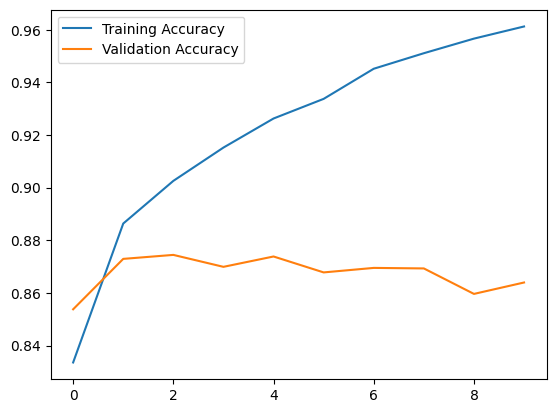

In [22]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

overfitting.. its fine till epochs 2 or 3. so reducing epochs. keeping only 3 epochs is better.

early_stopping = EarlyStopping(
    monitor='val_loss',   # Watch the validation loss
    patience=2,           # How many epochs to wait before giving up
    restore_best_weights=True # Rewind to the best version of the model
)

# Use it in your fit function
model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=10,
    callbacks=[early_stopping] # This is the magic line
)

In [24]:
y_pred = model.predict(X_test_lstm)

310/310 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step


In [25]:
y_pred_classes = (y_pred>0.5).astype("int32")

In [26]:
label_map = {
    1: "Positive",
    0: "Negative"
}
print("Top 10 predictions: ")
for i in range(10):
  actual = label_map[y_test_lstm.values[i]]
  predicted = label_map[y_pred_classes[i][0]]
  print(f"Sample {i+1}: Actual: {actual} | Predicted: {predicted}")

Top 10 predictions: 
Sample 1: Actual: Negative | Predicted: Negative
Sample 2: Actual: Positive | Predicted: Positive
Sample 3: Actual: Negative | Predicted: Positive
Sample 4: Actual: Negative | Predicted: Negative
Sample 5: Actual: Positive | Predicted: Positive
Sample 6: Actual: Positive | Predicted: Positive
Sample 7: Actual: Negative | Predicted: Negative
Sample 8: Actual: Negative | Predicted: Positive
Sample 9: Actual: Negative | Predicted: Negative
Sample 10: Actual: Positive | Predicted: Positive
